# Paso 05 -- Comparar el agente PPO (recompensa D) contra la politica base

Corre el agente entrenado con la recompensa **D** (tiempo cuadrático puro,
sin tolerancia -- `modelo_rl/output/modelo_final/`,
`modelo_rl/notebooks/01_enfoque_y_entrenamiento_final.ipynb`) y la política
base (`asignar_flota`) sobre las MISMAS semillas de evaluación
(`agente.evaluacion.semillas` en el config -- distintas de
`semilla_entrenamiento`, para no evaluar sobre demandas ya vistas), en la
misma instancia de entrenamiento (escalón chico). Misma semilla -> misma
demanda para las dos políticas (ver `modelo_rl/src/entrenamiento.py`), así
la comparación es justa.

**Cambio respecto a la versión anterior de este notebook (usaba B):**
`modelo_rl/notebooks/01_enfoque_y_entrenamiento_final.ipynb` se actualizó
(2026-09-17) para entrenar con la recompensa D en vez del combo C1, y a
150 000 timesteps en vez de 300 000 -- ver ese notebook y
`simulador/config/instance.yaml` -> `agente.entrenamiento` para el detalle.
D pasa a ser oficialmente el modelo final (`modelo_rl/output/modelo_final/`)
-- ya NO se reusa el modelo de `modelo_rl/prueba_rewards/` (esa carpeta
sigue como el experimento exploratorio de 8 recompensas, sin tocar). El
combo C1/300 000-timesteps anterior sigue documentado en
`modelo_rl/README.md`, no se borra -- solo deja de ser lo que este notebook
compara.

**Bug corregido en una versión anterior:** la versión con B calculaba la
recompensa reportada (para el agente Y para la base) con la config de B
(`recompensa_overrides` de B, pensada solo para el agente B) -- eso hacía
que la recompensa de la base no fuera comparable con la del agente si el
agente cambiaba de fórmula. Acá la config de recompensa que usan AMBOS
entornos (agente y base) es la de D, leída de una sola fuente
(`simulador/config/instance.yaml` -> `agente.entrenamiento.recompensa_overrides`)
-- ver la celda de configuración. (La política base en sí no usa esta
config para decidir -- `politica_base.asignar_flota` no lee `cfg_recompensa`
en su lógica, solo FIFO por urgencia -- así que este cambio no afecta el
COMPORTAMIENTO de la base, solo el reward que se le reporta.)

**Cómo se agregan los resultados:** igual que el escalón 3 (semana) -- cada
semilla de evaluación es su propio episodio independiente;
`metricas.combinar_corridas` junta los N episodios de cada política en un
solo objeto y `metricas.reporte_completo` da las mismas tablas de siempre,
ahora una por política, listas para comparar lado a lado. Cero funciones de
métricas nuevas.

**Objetivo de esta primera versión:** mostrar si el agente iguala o supera
a la política base -- no se exige que gane.

**Detalle de semillas concretas (más abajo):** además del agregado de las 5
semillas, se elige la MEJOR y la PEOR semilla para el agente por una
MÉTRICA REAL (`sistema_medio_min`, no el reward -- mismo criterio
anti-Goodhart que el resto del proyecto) y se genera, para esas dos, el
mismo paquete de métricas/gráficas que un notebook de escalón (perfil de
espera, ocupación de flota, heatmap por par, desglose de recompensa,
backlog por par, animación, reproductor interactivo) -- cada pieza en su
propia celda (no una función que hace todo junto), para poder correr o
saltarse cualquiera por separado.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
SIMULADOR_DIR = (BASE_DIR / "../simulador").resolve()
POLITICA_BASE_DIR = (BASE_DIR / "../politica_base").resolve()
MODELO_RL_DIR = (BASE_DIR / "../modelo_rl").resolve()
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
DEMAND_DIR = (BASE_DIR / "../demand").resolve()
sys.path.insert(0, str(DEMAND_DIR / "src"))
sys.path.insert(0, str(SIMULADOR_DIR / "src"))
sys.path.insert(0, str(POLITICA_BASE_DIR / "src"))
sys.path.insert(0, str(MODELO_RL_DIR / "src"))

import masas as demand_masas
import llegadas as demand_llegadas
from entrenamiento import EntornoDemandaAleatoria
from politica_base import asignar_flota
import metricas as met
import visualizacion as viz
from stable_baselines3 import PPO

cfg_sim = yaml.safe_load(open(SIMULADOR_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")

resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
conexiones_fuertes = cfg_bb["garantia"]["conexiones_fuertes"]

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)

cfg_agente = cfg_sim["agente"]
cfg_entren = cfg_agente["entrenamiento"]
cfg_escalon = cfg_sim["escalones"][cfg_entren["escalon_base"]]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60
semillas_eval = cfg_agente["evaluacion"]["semillas"]

# Config de recompensa D -- UNA sola fuente (simulador/config/instance.yaml ->
# agente.entrenamiento.recompensa_overrides, la MISMA que uso
# 01_enfoque_y_entrenamiento_final.ipynb para entrenar este modelo), usada
# para AMBOS entornos (agente y base) de abajo. Antes (version con B) esto
# salia de cfg_sim["recompensa"] + un override pensado solo para el agente B
# -- si la base y el agente no usan la MISMA formula de recompensa para que
# env.step() la calcule, el reward reportado de la base no es comparable con
# el del agente (bug corregido, ver la celda de arriba). `politica_base.
# asignar_flota` no LEE este cfg en su logica de decision (solo FIFO por
# urgencia) -- este cambio solo afecta que numero de reward se REPORTA, no
# el comportamiento de la base.
cfg_recompensa_eval = dict(cfg_sim["recompensa"])
cfg_recompensa_eval.update(cfg_entren.get("recompensa_overrides", {}))
print(f"Config de recompensa D (usada para AMBOS entornos, agente y base): {cfg_recompensa_eval}")

RL_DIR = MODELO_RL_DIR / "output" / "modelo_final"
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

model = PPO.load(str(RL_DIR / "modelo_ppo"))
print("Modelo cargado de", RL_DIR / "modelo_ppo.zip")
print(f"Instancia de evaluacion: {cfg_entren['escalon_base']}, semillas: {semillas_eval}")


def construir_entorno_eval():
    return EntornoDemandaAleatoria(
        generar_llegadas_dia_fn=demand_llegadas.generar_llegadas_dia,
        cfg_demand=cfg_demand, intensidad_od=intensidad_od, conexiones_fuertes=conexiones_fuertes,
        poblacion_total_zonas=poblacion_total_zonas, horas=cfg_escalon["horas"],
        porcentaje_poblacion_dia=cfg_escalon["porcentaje_poblacion_dia"],
        matriz_tiempos=matriz_tiempos, nodos=nodos, num_barcos=cfg_escalon["num_barcos"],
        capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"], nodo_inicial=cfg_bb["flota"]["nodo_inicial"],
        paso_tiempo_min=cfg_sim["paso_tiempo_min"], hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_recompensa_eval, unidad_demanda=cfg_sim["unidad_demanda"],
    )


# B.6: consistencia train/eval -- prueba estructural, no solo de nombre. Si el
# entrenamiento y esta evaluacion usaran escalones distintos (p.ej. entrenar en
# escalon_1, evaluar en escalon_2), la dimension del vector aplanado casi
# seguro seria distinta (depende de num_barcos) -- esto lo confirma en tiempo
# de ejecucion, no solo comparando la clave de config.
_dim_modelo = model.observation_space.shape
_dim_eval = construir_entorno_eval().observation_space.shape
assert _dim_modelo == _dim_eval, (
    f"Desajuste train/eval: el modelo espera observaciones de forma {_dim_modelo}, "
    f"pero {cfg_entren['escalon_base']} en esta evaluacion da {_dim_eval} -- entrenar y "
    f"evaluar deben usar el mismo escalon."
)
print(f"OK: train y eval usan el mismo escalon ({cfg_entren['escalon_base']}), "
      f"vector aplanado de forma {_dim_eval} en ambos.")

# VecNormalize (ver modelo_rl/README.md): si el entrenamiento final entreno con
# esto activo, hay que evaluar con las MISMAS estadisticas (congeladas, no se
# siguen actualizando) -- si no, el agente veria observaciones en una escala
# distinta a la que aprendio. `usar_vecnormalize_eval` se decide por la
# EXISTENCIA del archivo guardado, no leyendo el config (asi sigue
# funcionando si se evalua un modelo viejo entrenado sin esto).
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

VECNORMALIZE_PATH = RL_DIR / "vecnormalize.pkl"
usar_vecnormalize_eval = VECNORMALIZE_PATH.exists()
print(f"VecNormalize en evaluacion: {usar_vecnormalize_eval} "
      f"({'encontrado' if usar_vecnormalize_eval else 'no encontrado'} {VECNORMALIZE_PATH.name})")


Config de recompensa D (usada para AMBOS entornos, agente y base): {'tolerancia_incomodidad_min': 0, 'sobrante_normalizador_min': 12, 'penalizacion_maxima_persona': 100000000000.0, 'peso_movimiento': 0, 'premio_por_persona_entregada': 0}


Modelo cargado de C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\modelo_rl\output\modelo_final\modelo_ppo.zip
Instancia de evaluacion: escalon_1, semillas: [1001, 1002, 1003, 1004, 1005]
OK: train y eval usan el mismo escalon (escalon_1), vector aplanado de forma (46,) en ambos.
VecNormalize en evaluacion: True (encontrado vecnormalize.pkl)


## Correr las dos politicas sobre las mismas semillas de evaluacion

In [2]:
def correr_agente(semilla):
    if not usar_vecnormalize_eval:
        env = construir_entorno_eval()
        obs, info = env.reset(seed=semilla)
        reward_total = 0.0
        while True:
            accion, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = env.step(accion)
            reward_total += r
            if truncated or terminated:
                break
        return env, reward_total

    # Con VecNormalize: se steppea el entorno CRUDO directamente (NO a traves de
    # `venv.step()`) y solo se usan las estadisticas de VecNormalize para normalizar
    # la observacion antes de `predict()`. Se intento primero step-ear a traves del
    # DummyVecEnv (mas "de manual" de SB3) pero eso tiene un efecto secundario real:
    # `DummyVecEnv.step_wait()` AUTO-RESETEA el entorno interno en el mismo `step()`
    # en que `done=True` (comportamiento estandar de VecEnv, para no perder un paso
    # al encadenar episodios) -- eso borraba `atendidas_historico`/`log_eventos`
    # ANTES de poder leerlos, y `verificar_conservacion` daba todo en 0. Con el
    # entorno crudo (mismo patron ya usado y verificado en el diagnostico, ver
    # bitacora) el `reset()` lo controlamos nosotros, una sola vez, al principio.
    venv_stats = VecNormalize.load(str(VECNORMALIZE_PATH), DummyVecEnv([construir_entorno_eval]))
    venv_stats.training = False
    venv_stats.norm_reward = False  # comparar sobre recompensa CRUDA, igual que la politica base

    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        obs_norm = venv_stats.normalize_obs(obs)
        accion, _ = model.predict(obs_norm, deterministic=True)
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


def correr_base(semilla):
    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        decisiones = asignar_flota(libres, estado, matriz_tiempos, env.capacidad_barco, cfg_recompensa_eval)
        accion = np.array([
            env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
            for b in estado.barcos
        ])
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


envs_agente, envs_base = [], []
filas_reward = []
for semilla in semillas_eval:
    env_a, r_a = correr_agente(semilla)
    env_b, r_b = correr_base(semilla)
    envs_agente.append(env_a)
    envs_base.append(env_b)
    filas_reward.append({"semilla": semilla, "reward_agente": r_a, "reward_base": r_b, "diferencia": r_a - r_b})
    print(f"semilla {semilla}: agente={r_a:8.2f}  base={r_b:8.2f}  diferencia={r_a - r_b:+8.2f}")

df_reward = pd.DataFrame(filas_reward)
df_reward.to_csv(OUT_DIR / "reward_por_semilla.csv", index=False)
print(f"\nPromedio: agente={df_reward['reward_agente'].mean():.2f}  base={df_reward['reward_base'].mean():.2f}")


semilla 1001: agente=-7619.95  base=-1594.22  diferencia=-6025.73


semilla 1002: agente=-12861.51  base=-4527.19  diferencia=-8334.32
semilla 1003: agente=-7196.73  base=-3429.06  diferencia=-3767.67


semilla 1004: agente=-12591.87  base=-19679.64  diferencia=+7087.76
semilla 1005: agente=-6775.38  base=-1802.22  diferencia=-4973.16



Promedio: agente=-9409.09  base=-6206.46


## Combinar las 5 corridas de cada politica y sacar las metricas de siempre

Mismo mecanismo que el escalon 3 (`metricas.combinar_corridas` +
`metricas.reporte_completo`) -- aca cada "dia" es una semilla de
evaluacion distinta, en vez de un dia de la semana.

In [3]:
corrida_agente = met.combinar_corridas(envs_agente)
corrida_base = met.combinar_corridas(envs_base)

reporte_agente = met.reporte_completo(corrida_agente)
reporte_base = met.reporte_completo(corrida_base)

print("Conservacion agente:", reporte_agente["conservacion"]["cuadra"])
print("Conservacion base:  ", reporte_base["conservacion"]["cuadra"])


Conservacion agente: True
Conservacion base:   True


## Tabla comparativa (globales)

In [4]:
claves_comparar = [
    "unidades_generadas", "unidades_atendidas", "unidades_sin_atender_al_final",
    "pct_atendidas", "espera_media_min", "sistema_medio_min", "sistema_maximo_min",
]
tabla_comparativa = pd.DataFrame({
    "metrica": claves_comparar,
    "agente_ppo": [reporte_agente["globales"][k] for k in claves_comparar],
    "politica_base": [reporte_base["globales"][k] for k in claves_comparar],
})
tabla_comparativa["diferencia"] = tabla_comparativa["agente_ppo"] - tabla_comparativa["politica_base"]

# Recompensa total y movimientos/ocupacion de flota, tambien comparados
tabla_comparativa = pd.concat([tabla_comparativa, pd.DataFrame([
    {"metrica": "reward_total", "agente_ppo": df_reward["reward_agente"].sum(),
     "politica_base": df_reward["reward_base"].sum(),
     "diferencia": df_reward["reward_agente"].sum() - df_reward["reward_base"].sum()},
    {"metrica": "movimientos_totales", "agente_ppo": reporte_agente["por_barco"]["movimientos"].sum(),
     "politica_base": reporte_base["por_barco"]["movimientos"].sum(),
     "diferencia": reporte_agente["por_barco"]["movimientos"].sum() - reporte_base["por_barco"]["movimientos"].sum()},
    {"metrica": "ocupacion_media", "agente_ppo": reporte_agente["por_barco"]["ocupacion_media"].mean(),
     "politica_base": reporte_base["por_barco"]["ocupacion_media"].mean(),
     "diferencia": reporte_agente["por_barco"]["ocupacion_media"].mean() - reporte_base["por_barco"]["ocupacion_media"].mean()},
])], ignore_index=True)

tabla_comparativa.to_csv(OUT_DIR / "tabla_comparativa.csv", index=False)
display(tabla_comparativa.round(2))


,metrica,agente_ppo,politica_base,diferencia
0,unidades_generadas,850.00,850.00,0.00
1,unidades_atendidas,736.00,748.00,-12.00
2,unidades_sin_atender_al_final,114.00,102.00,12.00
3,pct_atendidas,86.59,88.00,-1.41
4,espera_media_min,19.81,16.42,3.39
5,sistema_medio_min,29.67,26.05,3.62
6,sistema_maximo_min,72.77,69.74,3.03
7,reward_total,-47045.43,-31032.31,-16013.12
8,movimientos_totales,190.00,155.00,35.00
9,ocupacion_media,3.43,3.50,-0.07


## Percentiles de espera/viaje/sistema (agregado, 5 semillas -- la base de una garantía de tiempo)

Mismo motivo que en cada escalón (`politica_base/README.md`): el simulador no pierde a nadie, así que los percentiles sobre las unidades atendidas son datos reales y sin censurar. Esto -- no solo el promedio -- es lo que permite proponer una garantía de servicio con sustento (p.ej. "95% de la gente esperó menos de X minutos").

In [5]:
percentiles_agente_agg = reporte_agente["por_usuario"]
percentiles_base_agg = reporte_base["por_usuario"]

filas_percentiles_agg = []
for metrica in ["espera_min", "viaje_min", "sistema_min"]:
    for pct in ["p50", "p90", "p95", "max"]:
        filas_percentiles_agg.append({
            "metrica": metrica, "percentil": pct,
            "agente_ppo": percentiles_agente_agg[metrica][pct],
            "politica_base": percentiles_base_agg[metrica][pct],
        })
tabla_percentiles_agregado = pd.DataFrame(filas_percentiles_agg)
tabla_percentiles_agregado["diferencia"] = tabla_percentiles_agregado["agente_ppo"] - tabla_percentiles_agregado["politica_base"]
tabla_percentiles_agregado.to_csv(OUT_DIR / "percentiles_agregado.csv", index=False)
display(tabla_percentiles_agregado.round(2))


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,16.23,13.93,2.30
1,espera_min,p90,42.60,37.19,5.41
2,espera_min,p95,52.43,46.06,6.37
3,espera_min,max,69.22,59.74,9.48
4,viaje_min,p50,10.00,10.00,0.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,26.75,22.98,3.77
9,sistema_min,p90,50.07,37.80,12.27


## Comparacion por par origen-destino

In [6]:
par_agente = reporte_agente["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
par_base = reporte_base["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
por_par_comparado = par_agente.merge(par_base, on="par", suffixes=("_agente", "_base"))
por_par_comparado.to_csv(OUT_DIR / "por_par_comparado.csv", index=False)
display(por_par_comparado.round(1))


,par,pct_atendidas_agente,espera_media_min_agente,sistema_medio_min_agente,pct_atendidas_base,espera_media_min_base,sistema_medio_min_base
0,kleppesto->laksevag,100.0,13.6,9.7,100.0,7.7,13.7
1,kleppesto->bryggen,87.5,17.4,27.5,80.8,17.0,24.9
2,kleppesto->sandviken,88.6,35.8,29.1,100.0,15.6,23.3
3,laksevag->kleppesto,100.0,19.3,48.8,100.0,25.3,58.8
4,laksevag->bryggen,80.1,21.7,31.8,85.7,23.1,28.3
5,laksevag->sandviken,60.0,15.1,25.1,60.0,27.1,37.1
6,bryggen->kleppesto,100.0,69.2,35.9,100.0,17.2,23.9
7,bryggen->laksevag,80.0,1.4,27.0,100.0,7.2,23.1
8,bryggen->sandviken,77.8,5.6,13.0,100.0,11.1,22.7
9,sandviken->kleppesto,100.0,19.4,29.4,100.0,16.2,26.2


## Comparación por barco -- ¿el agente simplemente no mueve la flota?

Dos tablas para responder esto con números, no con una impresión:
- **Por barco** (`metricas.metricas_por_barco`, ya existía): movimientos, tiempo navegado, ocupación, % ocioso, ruta más frecuente.
- **Decisiones** (`metricas.decisiones_por_barco`, nueva): cuántas veces cada barco decidió "esperar" en vez de moverse, y -- lo más diagnóstico -- cuántas de esas veces esperó TENIENDO demanda esperando en su propio nodo (una oportunidad perdida, no una espera justificada por falta de demanda).

In [7]:
barco_agente = reporte_agente["por_barco"][["barco_id", "movimientos", "tiempo_navegado_min", "tiempo_esperando_min", "ocupacion_media", "ocupacion_maxima", "pct_esperando"]]
barco_base = reporte_base["por_barco"][["barco_id", "movimientos", "tiempo_navegado_min", "tiempo_esperando_min", "ocupacion_media", "ocupacion_maxima", "pct_esperando"]]
por_barco_comparado = barco_agente.merge(barco_base, on="barco_id", suffixes=("_agente", "_base"))
por_barco_comparado.to_csv(OUT_DIR / "por_barco_comparado.csv", index=False)
display(por_barco_comparado.round(1))


,barco_id,movimientos_agente,tiempo_navegado_min_agente,tiempo_esperando_min_agente,ocupacion_media_agente,ocupacion_maxima_agente,pct_esperando_agente,movimientos_base,tiempo_navegado_min_base,tiempo_esperando_min_base,ocupacion_media_base,ocupacion_maxima_base,pct_esperando_base
0,barco_0,85,716,194,4.2,20,21.3,79,624,286,3.4,20,31.4
1,barco_1,105,686,224,2.7,20,24.6,76,600,310,3.6,20,34.1


In [8]:
decisiones_agente = met.decisiones_por_barco(corrida_agente)
decisiones_base = met.decisiones_por_barco(corrida_base)
decisiones_comparado = decisiones_agente.merge(decisiones_base, on="barco_id", suffixes=("_agente", "_base"))
decisiones_comparado.to_csv(OUT_DIR / "decisiones_por_barco_comparado.csv", index=False)
display(decisiones_comparado)

print(f"\nAgente: espero en {decisiones_agente['veces_espero'].sum()} de {decisiones_agente['decisiones_totales'].sum()} decisiones "
      f"({100*decisiones_agente['veces_espero'].sum()/decisiones_agente['decisiones_totales'].sum():.1f}%), "
      f"de las cuales {decisiones_agente['veces_espero_con_demanda_local'].sum()} fueron con demanda local esperando (oportunidad perdida).")
print(f"Base:   espero en {decisiones_base['veces_espero'].sum()} de {decisiones_base['decisiones_totales'].sum()} decisiones "
      f"({100*decisiones_base['veces_espero'].sum()/decisiones_base['decisiones_totales'].sum():.1f}%), "
      f"de las cuales {decisiones_base['veces_espero_con_demanda_local'].sum()} fueron con demanda local esperando.")


,barco_id,decisiones_totales_agente,veces_espero_agente,pct_espero_agente,veces_espero_con_demanda_local_agente,decisiones_totales_base,veces_espero_base,pct_espero_base,veces_espero_con_demanda_local_base
0,barco_0,94,9,9.574468,6,143,64,44.755245,0
1,barco_1,111,6,5.405405,1,152,76,50.000000,1



Agente: espero en 15 de 205 decisiones (7.3%), de las cuales 7 fueron con demanda local esperando (oportunidad perdida).
Base:   espero en 140 de 295 decisiones (47.5%), de las cuales 1 fueron con demanda local esperando.


## Graficas comparativas

In [9]:
from plotly.subplots import make_subplots

fig_a = viz.graficar_heatmap_cumplimiento(corrida_agente)
fig_b = viz.graficar_heatmap_cumplimiento(corrida_base)

fig = make_subplots(rows=1, cols=2, subplot_titles=["PPO agent -- % served by pair", "Base policy -- % served by pair"])
fig.add_trace(fig_a.data[0], row=1, col=1)
fig.add_trace(fig_b.data[0], row=1, col=2)
fig.update_xaxes(title_text="Destination", row=1, col=1)
fig.update_xaxes(title_text="Destination", row=1, col=2)
fig.update_yaxes(title_text="Origin", row=1, col=1)
fig.update_layout(title="Agent vs. base policy -- % served by O-D pair", template="plotly_white")
fig.write_html(OUT_DIR / "heatmaps_comparados.html")
fig.show()


In [10]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(x=[str(s) for s in semillas_eval], y=df_reward["reward_agente"], name="PPO agent", marker_color="#2980b9"))
fig.add_trace(go.Bar(x=[str(s) for s in semillas_eval], y=df_reward["reward_base"], name="base policy", marker_color="#e67e22"))
fig.update_layout(
    title="Evaluation-episode reward -- agent vs. base policy",
    xaxis_title="Evaluation seed", yaxis_title="Episode total reward",
    barmode="group", template="plotly_white",
)
fig.write_html(OUT_DIR / "reward_por_semilla.html")
fig.show()


## Elegir la mejor y la peor semilla para el agente -- por una métrica real, no por reward

**Por qué no por `reward_agente` de la tabla de arriba:** el reward es la
señal de entrenamiento, no la métrica de negocio -- compararlo entre
semillas para elegir "la mejor" sería el mismo error anti-Goodhart que el
resto de este proyecto evita al comparar políticas (`comparacion/README.md`,
`modelo_rl/prueba_rewards/README.md` sección 4). Acá se usa
`sistema_medio_min` (tiempo medio en sistema) del AGENTE en cada semilla,
calculado por separado para cada uno de los 5 episodios ya corridos arriba
(no hace falta volver a correr nada) -- menor es mejor.

In [11]:
filas_por_semilla = []
for semilla, env_a, env_b in zip(semillas_eval, envs_agente, envs_base):
    rep_a = met.reporte_completo(env_a)
    rep_b = met.reporte_completo(env_b)
    filas_por_semilla.append({
        "semilla": semilla,
        "sistema_medio_min_agente": rep_a["globales"]["sistema_medio_min"],
        "sistema_maximo_min_agente": rep_a["globales"]["sistema_maximo_min"],
        "sistema_medio_min_base": rep_b["globales"]["sistema_medio_min"],
    })

tabla_por_semilla = pd.DataFrame(filas_por_semilla)
tabla_por_semilla.to_csv(OUT_DIR / "metricas_por_semilla.csv", index=False)
display(tabla_por_semilla.round(2))

semilla_mejor = int(tabla_por_semilla.loc[tabla_por_semilla["sistema_medio_min_agente"].idxmin(), "semilla"])
semilla_peor = int(tabla_por_semilla.loc[tabla_por_semilla["sistema_medio_min_agente"].idxmax(), "semilla"])
SEMILLAS_DETALLE = [semilla_mejor, semilla_peor]
print(f"\nMejor semilla para el agente (menor tiempo medio en sistema): {semilla_mejor}")
print(f"Peor semilla para el agente (mayor tiempo medio en sistema):  {semilla_peor}")


,semilla,sistema_medio_min_agente,sistema_maximo_min_agente,sistema_medio_min_base
0,1001,24.98,62.83,18.60
1,1002,34.98,81.22,26.93
2,1003,28.33,62.43,23.53
3,1004,31.55,72.77,38.24
4,1005,29.02,70.62,21.26



Mejor semilla para el agente (menor tiempo medio en sistema): 1001
Peor semilla para el agente (mayor tiempo medio en sistema):  1002


## Detalle por semilla: la mejor y la peor para el agente (`SEMILLAS_DETALLE`)

Se reusan las corridas YA HECHAS arriba (`envs_agente`/`envs_base`, mismos
90 pasos, misma demanda para las dos políticas) -- no se vuelve a correr
nada.

**A propósito, cada pieza está en su propia celda** (animación, inspector,
reproductor, percentiles, perfil de espera, ocupación de flota, heatmap,
desglose de recompensa, backlog) -- no una función que hace todo junto, así
se puede correr o saltar cualquiera por separado (por ejemplo, si no
querés esperar el reproductor interactivo, simplemente no corrés esa
celda).

**Sobre el reproductor interactivo, específicamente:** cada semilla tiene
su PROPIA celda dedicada (no un `for semilla in ...` compartido) -- con
varios widgets de `ipywidgets` creados en un mismo bucle, solo el último
terminaba respondiendo de forma confiable (reportado: con dos semillas
corridas juntas, el reproductor de la primera se quedaba sin reaccionar).
Una celda por semilla evita ese problema de raíz.

In [12]:
gdf_nodos, gdf_rutas = viz.cargar_capas_mapa(cfg_bb, BB_DIR / "02_ruteo_navegable" / "output" / "rutas_navegables.geojson")

# El fondo se descarga UNA sola vez y se reusa en las 2 animaciones + inspectores + reproductores de abajo.
fondo_mapa = viz.descargar_fondo_mapa(gdf_nodos)


### Encabezado por semilla, atendidas

In [13]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]
    etiqueta = "MEJOR" if semilla == semilla_mejor else "PEOR"
    print(f"\nSEMILLA {semilla} ({etiqueta} para el agente)")
    print("=" * 70)
    print(f"Agente: {len(env_a.atendidas_historico)}/{env_a.total_unidades_generadas} atendidas")
    print(f"Base:   {len(env_b.atendidas_historico)}/{env_b.total_unidades_generadas} atendidas")



SEMILLA 1001 (MEJOR para el agente)
Agente: 98/135 atendidas
Base:   124/135 atendidas

SEMILLA 1002 (PEOR para el agente)
Agente: 126/150 atendidas
Base:   137/150 atendidas


### Animaciones (GIF)

In [14]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    out_gif_agente = OUT_DIR / f"animacion_agente_semilla{semilla}.gif"
    viz.animar_corrida(env_a.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env_a.capacidad_barco, out_gif_agente, fps=6, fondo=fondo_mapa)
    print("Guardado:", out_gif_agente)
    plt.close("all")

    out_gif_base = OUT_DIR / f"animacion_base_semilla{semilla}.gif"
    viz.animar_corrida(env_b.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env_b.capacidad_barco, out_gif_base, fps=6, fondo=fondo_mapa)
    print("Guardado:", out_gif_base)
    plt.close("all")


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_agente_semilla1001.gif


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_base_semilla1001.gif


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_agente_semilla1002.gif


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_base_semilla1002.gif


### Inspector en minutos concretos

**Sobre los minutos -- corregido en una versión anterior:** `escalon_1`
arranca en el minuto 360 del día (06:00), no en el minuto 0. Pedir
`inspeccionar(40, ...)` o `inspeccionar(100, ...)` a secas cae MUY antes de
que la corrida empiece -- el inspector cae al frame más cercano disponible,
que siempre termina siendo el primero (minuto 360), sea 40 o 100 lo que se
pida. Acá se piden minutos RELATIVOS al inicio de la corrida
(`hora_ini_min + 40`, `hora_ini_min + 100` -- 400 y 460 para `escalon_1`),
que sí caen dentro de la ventana simulada.


=== AGENTE, semilla 1001, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: K->B (8 min), ocupación=9
  barco_1: B->L (1 min), ocupación=0

Colas (pares con gente esperando):
  L->K: 8 personas, la más antigua lleva 17.3 min

Recompensa del paso: -65.460
  incomodidad = 65.460
  movimiento  = 0.000


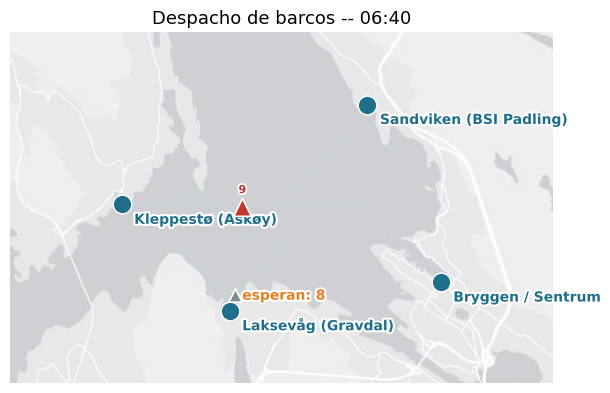


=== BASE, semilla 1001, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: B->L (7 min), ocupación=0
  barco_1: S->B (3 min), ocupación=10

Colas (pares con gente esperando):
  L->K: 8 personas, la más antigua lleva 17.3 min

Recompensa del paso: -57.609
  incomodidad = 57.609
  movimiento  = 0.000


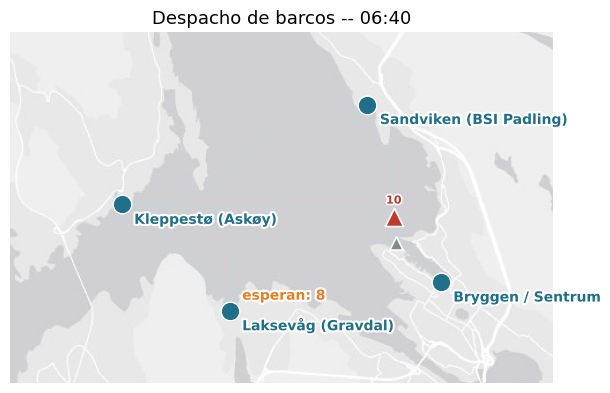


=== AGENTE, semilla 1001, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: B->K (6 min), ocupación=0
  barco_1: K->L (1 min), ocupación=0

Colas (pares con gente esperando):
  (ninguna)

Recompensa del paso: 0.000
  incomodidad = 0.000
  movimiento  = 0.000


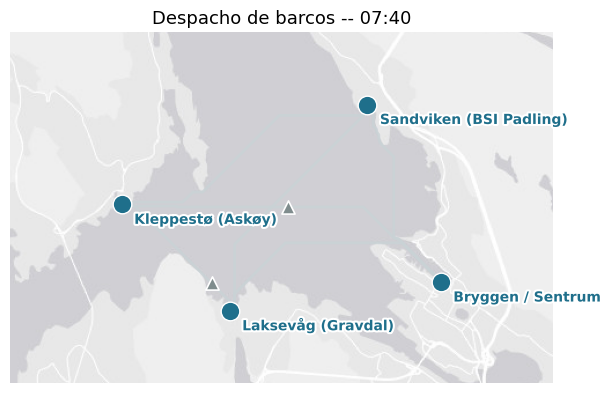


=== BASE, semilla 1001, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: esperar
  barco_1: libre, ocupación=0, decidió: esperar

Colas (pares con gente esperando):
  (ninguna)

Recompensa del paso: 0.000
  incomodidad = 0.000
  movimiento  = 0.000


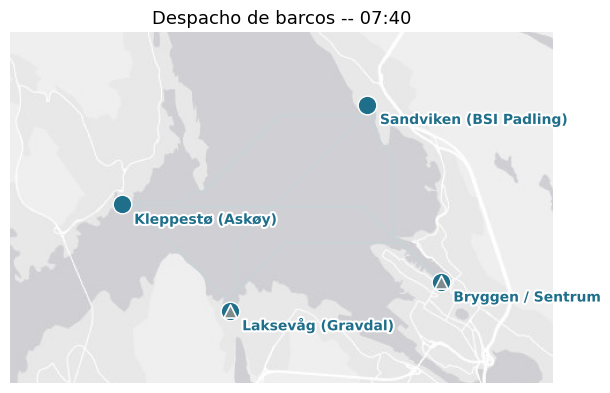


=== AGENTE, semilla 1002, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: K->L (1 min), ocupación=0
  barco_1: B->L (1 min), ocupación=0

Colas (pares con gente esperando):
  K->B: 13 personas, la más antigua lleva 15.8 min
  L->B: 21 personas, la más antigua lleva 31.2 min

Recompensa del paso: -71.591
  incomodidad = 71.591
  movimiento  = 0.000


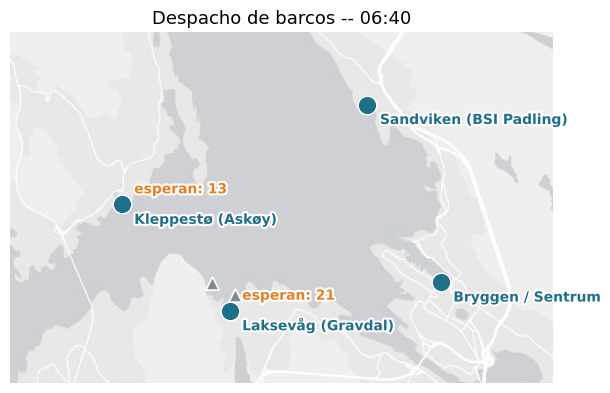


=== BASE, semilla 1002, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: S->K (8 min), ocupación=0
  barco_1: B->K (10 min), ocupación=0

Colas (pares con gente esperando):
  K->B: 13 personas, la más antigua lleva 15.8 min
  L->B: 17 personas, la más antigua lleva 15.3 min

Recompensa del paso: -44.481
  incomodidad = 44.481
  movimiento  = 0.000


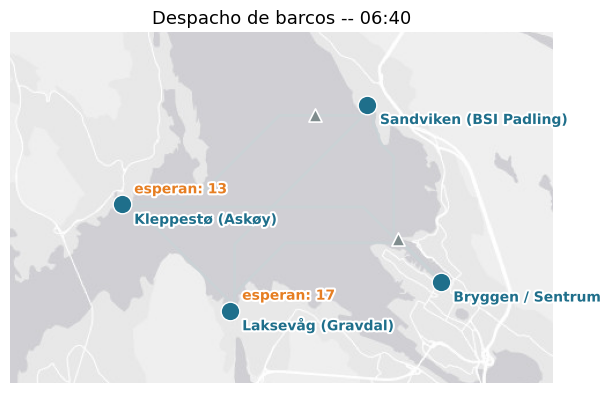


=== AGENTE, semilla 1002, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: laksevag
  barco_1: L->S (7 min), ocupación=0

Colas (pares con gente esperando):
  K->S: 9 personas, la más antigua lleva 15.7 min
  B->K: 8 personas, la más antigua lleva 21.2 min
  S->L: 6 personas, la más antigua lleva 17.0 min
  S->B: 3 personas, la más antigua lleva 36.1 min

Recompensa del paso: -79.621
  incomodidad = 79.621
  movimiento  = 0.000


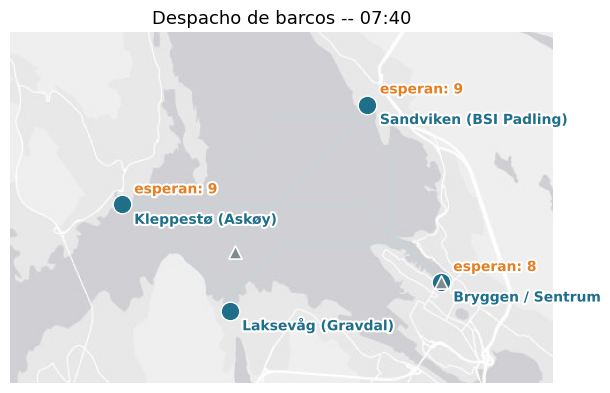


=== BASE, semilla 1002, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: S->L (7 min), ocupación=6
  barco_1: B->K (8 min), ocupación=8

Colas (pares con gente esperando):
  L->B: 11 personas, la más antigua lleva 31.8 min

Recompensa del paso: -107.502
  incomodidad = 107.502
  movimiento  = 0.000


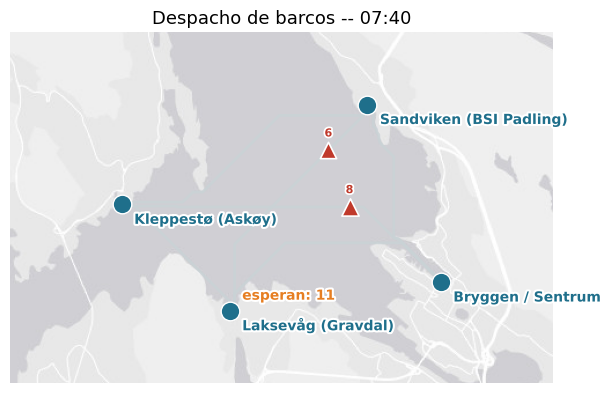

In [15]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]
    for offset in [40, 100]:
        minuto = hora_ini_min + offset
        print(f"\n=== AGENTE, semilla {semilla}, minuto {minuto} (inicio+{offset}) ===")
        viz.inspeccionar(minuto, env_a, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
        plt.show()
        print(f"\n=== BASE, semilla {semilla}, minuto {minuto} (inicio+{offset}) ===")
        viz.inspeccionar(minuto, env_b, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
        plt.show()


### Reproductor interactivo (video con play/pausa/barra de tiempo)

Solo funciona con un kernel de Jupyter VIVO (ver docstring de
`visualizacion.reproductor_interactivo`) -- no se ve en un notebook ya
ejecutado/guardado (`nbconvert`). **Cada reproductor está en su PROPIA
celda** (agente y base, para cada semilla, cuatro celdas en total) -- no
un `for` compartido: con varios widgets `ipywidgets` creados en el mismo
bucle, solo el último terminaba respondiendo de forma confiable. Si no
te interesa el reproductor de alguna combinación, simplemente no corras
esa celda.

In [16]:
# Reproductor: AGENTE, semilla mejor
idx = semillas_eval.index(semilla_mejor)
print(f"=== Reproductor: AGENTE, semilla {semilla_mejor} (MEJOR) ===")
viz.reproductor_interactivo(envs_agente[idx], gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)


=== Reproductor: AGENTE, semilla 1001 (MEJOR) ===


In [17]:
# Reproductor: BASE, semilla mejor
idx = semillas_eval.index(semilla_mejor)
print(f"=== Reproductor: BASE, semilla {semilla_mejor} (MEJOR) ===")
viz.reproductor_interactivo(envs_base[idx], gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)


=== Reproductor: BASE, semilla 1001 (MEJOR) ===


In [18]:
# Reproductor: AGENTE, semilla peor
idx = semillas_eval.index(semilla_peor)
print(f"=== Reproductor: AGENTE, semilla {semilla_peor} (PEOR) ===")
viz.reproductor_interactivo(envs_agente[idx], gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)


=== Reproductor: AGENTE, semilla 1002 (PEOR) ===


In [19]:
# Reproductor: BASE, semilla peor
idx = semillas_eval.index(semilla_peor)
print(f"=== Reproductor: BASE, semilla {semilla_peor} (PEOR) ===")
viz.reproductor_interactivo(envs_base[idx], gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)


=== Reproductor: BASE, semilla 1002 (PEOR) ===


### Percentiles de espera/viaje/sistema, por semilla

In [20]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]
    reporte_a = met.reporte_completo(env_a)
    reporte_b = met.reporte_completo(env_b)
    percentiles_a, percentiles_b = reporte_a["por_usuario"], reporte_b["por_usuario"]

    filas = []
    for metrica in ["espera_min", "viaje_min", "sistema_min"]:
        for pct in ["p50", "p90", "p95", "max"]:
            filas.append({"metrica": metrica, "percentil": pct,
                           "agente_ppo": percentiles_a[metrica][pct],
                           "politica_base": percentiles_b[metrica][pct]})
    tabla = pd.DataFrame(filas)
    tabla["diferencia"] = tabla["agente_ppo"] - tabla["politica_base"]
    tabla.to_csv(OUT_DIR / f"percentiles_semilla{semilla}.csv", index=False)
    print(f"\nPercentiles, semilla {semilla}:")
    display(tabla.round(2))



Percentiles, semilla 1001:


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,12.08,8.54,3.54
1,espera_min,p90,30.58,20.27,10.31
2,espera_min,p95,52.83,25.34,27.49
3,espera_min,max,52.83,25.34,27.49
4,viaje_min,p50,8.00,8.00,0.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,20.54,16.54,4.00
9,sistema_min,p90,40.58,28.27,12.31



Percentiles, semilla 1002:


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,17.32,15.61,1.71
1,espera_min,p90,55.71,31.32,24.39
2,espera_min,p95,69.22,36.53,32.69
3,espera_min,max,69.22,39.80,29.42
4,viaje_min,p50,10.00,10.00,0.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,27.32,24.97,2.35
9,sistema_min,p90,65.71,41.32,24.39


### Perfil de espera en el tiempo, por semilla

In [21]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    print(f"=== AGENTE, semilla {semilla} -- perfil de espera ===")
    fig = viz.graficar_perfil_espera(env_a)
    fig.write_html(str(OUT_DIR / f"wait_profile_agente_semilla{semilla}.html"))
    fig.show()

    print(f"=== BASE, semilla {semilla} -- perfil de espera ===")
    fig = viz.graficar_perfil_espera(env_b)
    fig.write_html(str(OUT_DIR / f"wait_profile_base_semilla{semilla}.html"))
    fig.show()


=== AGENTE, semilla 1001 -- perfil de espera ===


=== BASE, semilla 1001 -- perfil de espera ===


=== AGENTE, semilla 1002 -- perfil de espera ===


=== BASE, semilla 1002 -- perfil de espera ===


### Ocupación de flota en el tiempo, por semilla

In [22]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    print(f"=== AGENTE, semilla {semilla} -- ocupacion de flota ===")
    fig = viz.graficar_ocupacion_flota(env_a)
    fig.write_html(str(OUT_DIR / f"fleet_occupancy_agente_semilla{semilla}.html"))
    fig.show()

    print(f"=== BASE, semilla {semilla} -- ocupacion de flota ===")
    fig = viz.graficar_ocupacion_flota(env_b)
    fig.write_html(str(OUT_DIR / f"fleet_occupancy_base_semilla{semilla}.html"))
    fig.show()


=== AGENTE, semilla 1001 -- ocupacion de flota ===


=== BASE, semilla 1001 -- ocupacion de flota ===


=== AGENTE, semilla 1002 -- ocupacion de flota ===


=== BASE, semilla 1002 -- ocupacion de flota ===


### Heatmap de cumplimiento por par, por semilla

In [23]:
from plotly.subplots import make_subplots

for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    fig_a = viz.graficar_heatmap_cumplimiento(env_a)
    fig_b = viz.graficar_heatmap_cumplimiento(env_b)
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f"PPO agent -- seed {semilla}", f"Base policy -- seed {semilla}"])
    fig.add_trace(fig_a.data[0], row=1, col=1)
    fig.add_trace(fig_b.data[0], row=1, col=2)
    fig.update_xaxes(title_text="Destination", row=1, col=1)
    fig.update_xaxes(title_text="Destination", row=1, col=2)
    fig.update_yaxes(title_text="Origin", row=1, col=1)
    fig.update_layout(title=f"Agent vs. base policy -- % served by O-D pair (seed {semilla})", template="plotly_white")
    fig.write_html(str(OUT_DIR / f"pct_served_heatmap_comparado_semilla{semilla}.html"))
    fig.show()


### Desglose de recompensa (formula D, misma para agente y base), por semilla

In [24]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    print(f"=== AGENTE, semilla {semilla} -- desglose de recompensa ===")
    fig = viz.graficar_desglose_recompensa(env_a)
    fig.write_html(str(OUT_DIR / f"reward_breakdown_agente_semilla{semilla}.html"))
    fig.show()

    print(f"=== BASE, semilla {semilla} -- desglose de recompensa ===")
    fig = viz.graficar_desglose_recompensa(env_b)
    fig.write_html(str(OUT_DIR / f"reward_breakdown_base_semilla{semilla}.html"))
    fig.show()


=== AGENTE, semilla 1001 -- desglose de recompensa ===


=== BASE, semilla 1001 -- desglose de recompensa ===


=== AGENTE, semilla 1002 -- desglose de recompensa ===


=== BASE, semilla 1002 -- desglose de recompensa ===


### Backlog por par (sin atender al cierre), por semilla

In [25]:
for semilla in SEMILLAS_DETALLE:
    idx = semillas_eval.index(semilla)
    env_a, env_b = envs_agente[idx], envs_base[idx]

    print(f"=== AGENTE, semilla {semilla} -- backlog por par ===")
    fig = viz.graficar_sin_atender_al_final(env_a)
    fig.write_html(str(OUT_DIR / f"backlog_by_pair_agente_semilla{semilla}.html"))
    fig.show()

    print(f"=== BASE, semilla {semilla} -- backlog por par ===")
    fig = viz.graficar_sin_atender_al_final(env_b)
    fig.write_html(str(OUT_DIR / f"backlog_by_pair_base_semilla{semilla}.html"))
    fig.show()


=== AGENTE, semilla 1001 -- backlog por par ===


=== BASE, semilla 1001 -- backlog por par ===


=== AGENTE, semilla 1002 -- backlog por par ===


=== BASE, semilla 1002 -- backlog por par ===
